# Movie Revenue Analysis: What Drives Box Office Performance?

This notebook analyzes whether higher production budgets are associated with stronger worldwide revenue.  
The goal is not just to explore the data, but to translate the findings into **business insights** that can inform movie investment, release strategy, and risk evaluation.

**Business question:**  
How strongly does production budget influence worldwide box office revenue, and does that relationship change across film eras?


## 1. Setup and Imports


In [42]:
import pandas as pd
import matplotlib.pyplot as plt


## 2. Notebook Display Settings


In [43]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

## 3. Load the Dataset


In [ ]:
data = pd.read_csv('data/raw/cost_revenue_dirty.csv')


## 4. Data Quality Review and Cleaning


### Key questions
1. How large is the dataset?
2. Are there missing values or duplicates that could distort the analysis?
3. Which fields need type conversion before analysis?


In [45]:
print(f"The dataset consists of {data.shape[0]} rows and {data.shape[1]} columns.")
print(f"Null status: {True in data.isna().values}")
print(f"Duplicate status: {True in data.duplicated().values}")
print("#######################################################################################")
print(f"Data types: {data.info()}")


The dataset consists of 5391 rows and 6 columns.
Null status: False
Duplicate status: False
#######################################################################################
<class 'pandas.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Rank                   5391 non-null   int64
 1   Release_Date           5391 non-null   str  
 2   Movie_Title            5391 non-null   str  
 3   USD_Production_Budget  5391 non-null   str  
 4   USD_Worldwide_Gross    5391 non-null   str  
 5   USD_Domestic_Gross     5391 non-null   str  
dtypes: int64(1), str(5)
memory usage: 252.8 KB
Data types: None


### Standardize numeric fields
The budget and revenue columns are stored as strings with currency symbols.  
They need to be converted into numeric values before we can measure averages, losses, and trends.


**Challenge**: Convert the `USD_Production_Budget`, `USD_Worldwide_Gross`, and `USD_Domestic_Gross` columns to a numeric format by removing `$` signs and `,`. 
<br>
<br>
Note that *domestic* in this context refers to the United States.

In [46]:
data["USD_Domestic_Gross"] = data["USD_Domestic_Gross"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)
data["USD_Production_Budget"] = data["USD_Production_Budget"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)
data["USD_Worldwide_Gross"] = data["USD_Worldwide_Gross"].astype(str).str.replace(r"[\$,]", "", regex=True).astype(float)



### Convert release date to datetime
A proper datetime format is required for timeline analysis, decade grouping, and separating released vs unreleased films.


In [47]:
data.Release_Date = pd.to_datetime(data.Release_Date)

In [48]:
data.head(2)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,"110,000.00","11,000,000.00","10,000,000.00"
1,5140,1916-05-09,Intolerance,"385,907.00",0.00,0.00


## 5. Baseline Financial Profile of the Dataset


### Business questions
- What does the typical movie budget look like?
- What is the average worldwide revenue?
- Which films sit at the extreme ends of budget and revenue?
- What do the lower-budget titles look like compared with the rest of the market?


In [49]:
import numpy as np

# 1. Average production budget
print(f"Movie's average production budget is: ${data['USD_Production_Budget'].mean():,.2f}")

# 2. Average worldwide gross
print(f"\nThe average worldwide gross revenue for movies is: ${data['USD_Worldwide_Gross'].mean():,.2f}")

# 3. Minimum worldwide gross movie
print("\nThe movie with the minimum worldwide revenue is:")
print(data.loc[data["USD_Worldwide_Gross"].idxmin()])

# 4. Bottom 25% (Q1)
print("\nBottom 25% of production budgets:")
q1 = data["USD_Production_Budget"].quantile(0.25)
bottom_25 = data[data["USD_Production_Budget"] <= q1]
print(bottom_25.head())

# 5. Highest values
print(f"\nHighest production budget: ${data['USD_Production_Budget'].max():,.2f}")
print(f"Highest worldwide gross revenue: ${data['USD_Worldwide_Gross'].max():,.2f}")

# 6. Highest & lowest budget movies
print("\nHighest budget movie:")
print(data.loc[data["USD_Production_Budget"].idxmax()])

print("\nLowest budget movie:")
print(data.loc[data["USD_Production_Budget"].idxmin()])

Movie's average production budget is: $31,113,737.58

The average worldwide gross revenue for movies is: $88,855,421.96

The movie with the minimum worldwide revenue is:
Rank                                    5140
Release_Date             1916-05-09 00:00:00
Movie_Title                      Intolerance
USD_Production_Budget             385,907.00
USD_Worldwide_Gross                     0.00
USD_Domestic_Gross                      0.00
Name: 1, dtype: object

Bottom 25% of production budgets:
   Rank Release_Date                     Movie_Title  USD_Production_Budget  \
0  5293   1915-08-02           The Birth of a Nation             110,000.00   
1  5140   1916-05-09                     Intolerance             385,907.00   
2  5230   1916-12-24    20,000 Leagues Under the Sea             200,000.00   
3  5299   1920-09-17  Over the Hill to the Poorhouse             100,000.00   
4  5222   1925-01-01                  The Big Parade             245,000.00   

   USD_Worldwide_Gross  USD

### Insight
The descriptive statistics provide a quick benchmark for what a “typical” film looks like financially.  
This is useful for spotting outliers, understanding budget concentration, and framing later discussions around risk and scale.


## 6. Revenue Gaps and Commercial Risk


### Domestic underperformance
This section checks how many films generated **zero domestic revenue** and identifies the most expensive examples.  
From a business perspective, these titles represent distribution, release, or market-fit risk in the United States.


In [50]:
# Movies that grossed $0 domestically
domestic_movies_rev_losses = data[data["USD_Domestic_Gross"] == 0]

# Count
print(f"Number of movies with $0 domestic gross: {len(domestic_movies_rev_losses)}")

# Sort by highest production budget
sorted_losses = domestic_movies_rev_losses.sort_values(
    by="USD_Production_Budget",
    ascending=False
)

print("\nTop budget movies with $0 domestic gross:")
print(sorted_losses.head())

Number of movies with $0 domestic gross: 512

Top budget movies with $0 domestic gross:
      Rank Release_Date                         Movie_Title  \
5388    96   2020-12-31                         Singularity   
5387   126   2018-12-18                             Aquaman   
5384   321   2018-09-03                   A Wrinkle in Time   
5385   366   2018-10-08                      Amusement Park   
5090   556   2015-12-31  Don Gato, el inicio de la pandilla   

      USD_Production_Budget  USD_Worldwide_Gross  USD_Domestic_Gross  
5388         175,000,000.00                 0.00                0.00  
5387         160,000,000.00                 0.00                0.00  
5384         103,000,000.00                 0.00                0.00  
5385         100,000,000.00                 0.00                0.00  
5090          80,000,000.00         4,547,660.00                0.00  


### Worldwide zero-revenue titles
Movies with zero worldwide gross represent the most severe commercial failure in the dataset.  
These cases are useful for understanding how capital can be tied up without visible revenue realization.


In [51]:
# Movies that grossed $0 worldwide
zero_worldwide_movies = data[data["USD_Worldwide_Gross"] == 0]

# Count
print(f"Number of movies with $0 worldwide gross: {len(zero_worldwide_movies)}")

# Sort by highest production budget
sorted_losses = zero_worldwide_movies.sort_values(
    by="USD_Production_Budget",
    ascending=False
)

print("\nTop budget movies with $0 worldwide gross:")
print(sorted_losses.head())
sorted_losses.head(1)


Number of movies with $0 worldwide gross: 357

Top budget movies with $0 worldwide gross:
      Rank Release_Date        Movie_Title  USD_Production_Budget  \
5388    96   2020-12-31        Singularity         175,000,000.00   
5387   126   2018-12-18            Aquaman         160,000,000.00   
5384   321   2018-09-03  A Wrinkle in Time         103,000,000.00   
5385   366   2018-10-08     Amusement Park         100,000,000.00   
5058   880   2015-11-12   The Ridiculous 6          60,000,000.00   

      USD_Worldwide_Gross  USD_Domestic_Gross  
5388                 0.00                0.00  
5387                 0.00                0.00  
5384                 0.00                0.00  
5385                 0.00                0.00  
5058                 0.00                0.00  


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,"175,000,000.00",0.00,0.00


### Insight
Zero-revenue titles are extreme downside cases.  
For a studio or investor, these entries highlight the importance of release readiness, audience demand, and distribution execution before committing large budgets.


### International wins, domestic misses


Some films earn money globally while contributing nothing in the U.S. market.  
This pattern is important because it suggests that **international performance can partially offset domestic weakness**.


In [52]:
intl_success_domestic_fail = data.query(
    "USD_Worldwide_Gross > 0 and USD_Domestic_Gross == 0"
).sort_values(by="USD_Worldwide_Gross",ascending=False)

print(f"Movies that succeeded internationally but not domestically: {len(intl_success_domestic_fail)}")

Movies that succeeded internationally but not domestically: 155


### Insight
A film can fail domestically and still create value internationally.  
This suggests that worldwide strategy matters, especially for titles with stronger overseas appeal than U.S. traction.


## 7. Remove Unreleased Titles Before Measuring Performance

The dataset was scraped on **May 1, 2018**, so any movie with a release date on or after that day had not fully entered the market yet.  
Including them would understate revenue and distort profitability analysis.


In [53]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')

In [54]:
unreleased_movies = data.query(
    "Release_Date >= @scrape_date"
)

print(f"Number of unreleased movies: {len(unreleased_movies)}")

Number of unreleased movies: 7


In [ ]:
data_clean = data.drop(unreleased_movies.index)

data_clean.to_csv('data/processed/cleaned.csv', index=False)


## 8. Profitability Snapshot


In [56]:
loss_movies = data_clean.query(
    "USD_Production_Budget > USD_Worldwide_Gross"
)

perc_of_money_loss = (len(loss_movies) / len(data_clean)) * 100

print(f"Percentage of movies that lost money: {perc_of_money_loss:.2f}%")

Percentage of movies that lost money: 37.28%


### Insight
The share of films that failed to recover production budget from worldwide gross gives a direct measure of market risk.  
Even before marketing and distribution costs are considered, not every production budget translates into commercial success.


## 9. Visual Analysis: Budget and Revenue Patterns


In [57]:
import seaborn as sns

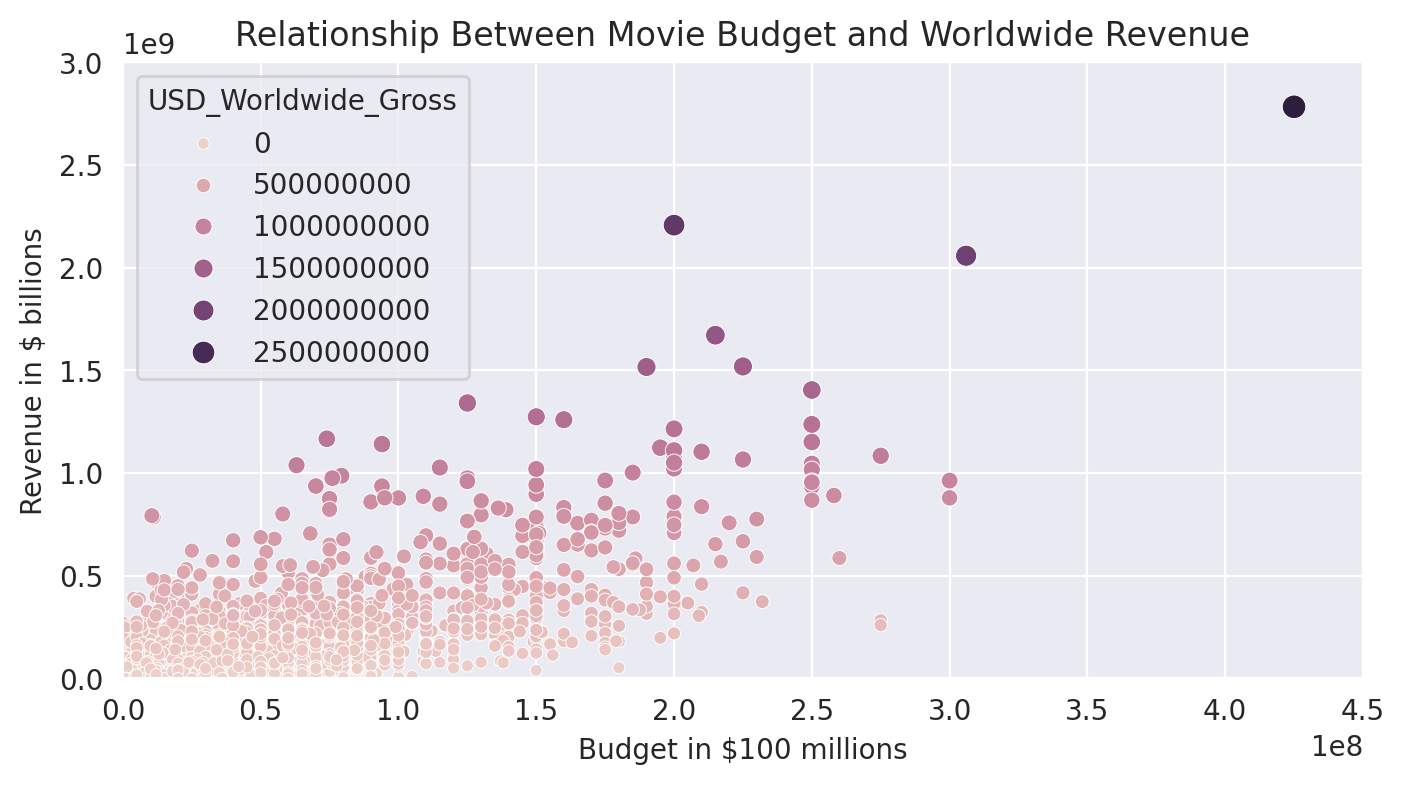

In [58]:
plt.figure(figsize=(8,4), dpi=200)

with sns.axes_style("darkgrid"):
    ax = sns.scatterplot(
        data_clean,
        x="USD_Production_Budget",
        y="USD_Worldwide_Gross",
        hue="USD_Worldwide_Gross",
        size="USD_Worldwide_Gross"
    )
    ax.set(
        ylim=(0, 3000000000),
        xlim=(0, 450000000),
        ylabel='Worldwide revenue ($)',
        xlabel='Production budget ($)',
        title="Relationship Between Movie Budget and Worldwide Revenue"
    )

plt.tight_layout()
plt.savefig("../visuals/budget_vs_revenue.png", dpi=300)


### Budget growth over time

This chart helps answer a business question:  
**Have production budgets increased over time, and are larger budgets associated with higher-revenue titles?**


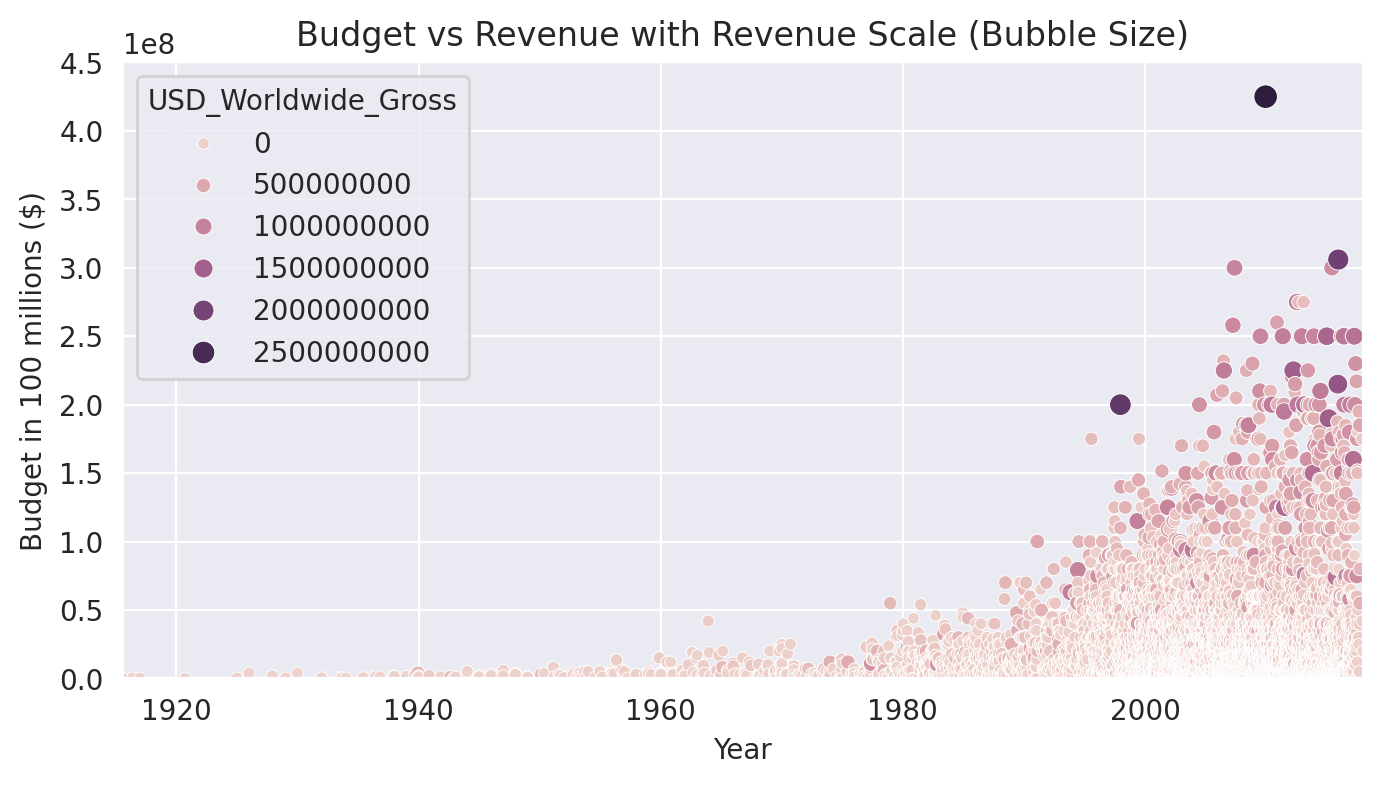

In [59]:
plt.figure(figsize=(8,4), dpi=200)

with sns.axes_style("darkgrid"):
    ax = sns.scatterplot(
        data_clean,
        x="Release_Date",
        y="USD_Production_Budget",
        hue="USD_Worldwide_Gross",
        size="USD_Worldwide_Gross"
    )

    ax.set(
        ylim=(0, 450_000_000),
        xlim=(data_clean.Release_Date.min(), data_clean.Release_Date.max()),
        xlabel="Release year",
        ylabel="Production budget ($)",
        title="Growth of Movie Production Budgets Over Time"
    )

plt.tight_layout()
plt.savefig("../visuals/budget_trend.png", dpi=300)


### Insight
The time-based bubble chart shows whether larger production budgets have become more common over time and whether top-grossing films cluster among recent releases.  
That matters because changing industry scale can affect how predictive historical comparisons really are.


## 10. Segment the Market by Era

To compare film economics across time, we create a decade field and split the market into:
- **Old films:** before 1970
- **Modern films:** 1970 onward

This allows us to see whether the budget-revenue relationship became stronger in the modern era.


In [ ]:
decade = (pd.DatetimeIndex(data_clean.Release_Date).year // 10).astype(int) * 10

data_clean["Decade"] = decade

data_clean.to_csv("data/processed/cleaned_with_decade.csv", index=False)

data_clean.head()


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
0,5293,1915-08-02,The Birth of a Nation,"110,000.00","11,000,000.00","10,000,000.00",1910
1,5140,1916-05-09,Intolerance,"385,907.00",0.00,0.00,1910
2,5230,1916-12-24,"20,000 Leagues Under the Sea","200,000.00","8,000,000.00","8,000,000.00",1910
3,5299,1920-09-17,Over the Hill to the Poorhouse,"100,000.00","3,000,000.00","3,000,000.00",1920
4,5222,1925-01-01,The Big Parade,"245,000.00","22,000,000.00","11,000,000.00",1920


### Create old vs modern film segments


In [ ]:
old_films = data_clean.query("Decade < 1970")
new_films = data_clean.query("Decade >= 1970")

old_films.to_csv("data/raw/old_films.csv", index=False)
new_films.to_csv("data/raw/new_films.csv", index=False)

print(f"{len(old_films)} movies were released before 1970.")
print(f"{len(new_films)} movies were released from 1970 onward.")
print(
    f"The most expensive pre-1970 film was "
    f"{old_films.Movie_Title.loc[old_films.USD_Production_Budget.idxmax()]}, "
    f"with a production budget of ${old_films.USD_Production_Budget.loc[old_films.USD_Production_Budget.idxmax()]:,.0f}."
)


153 movies were released before 1970s.
The most expensive film made before 1970s was: Cleopatra, with a production budget of :$42,000,000.0


## 11. Regression Analysis by Film Era


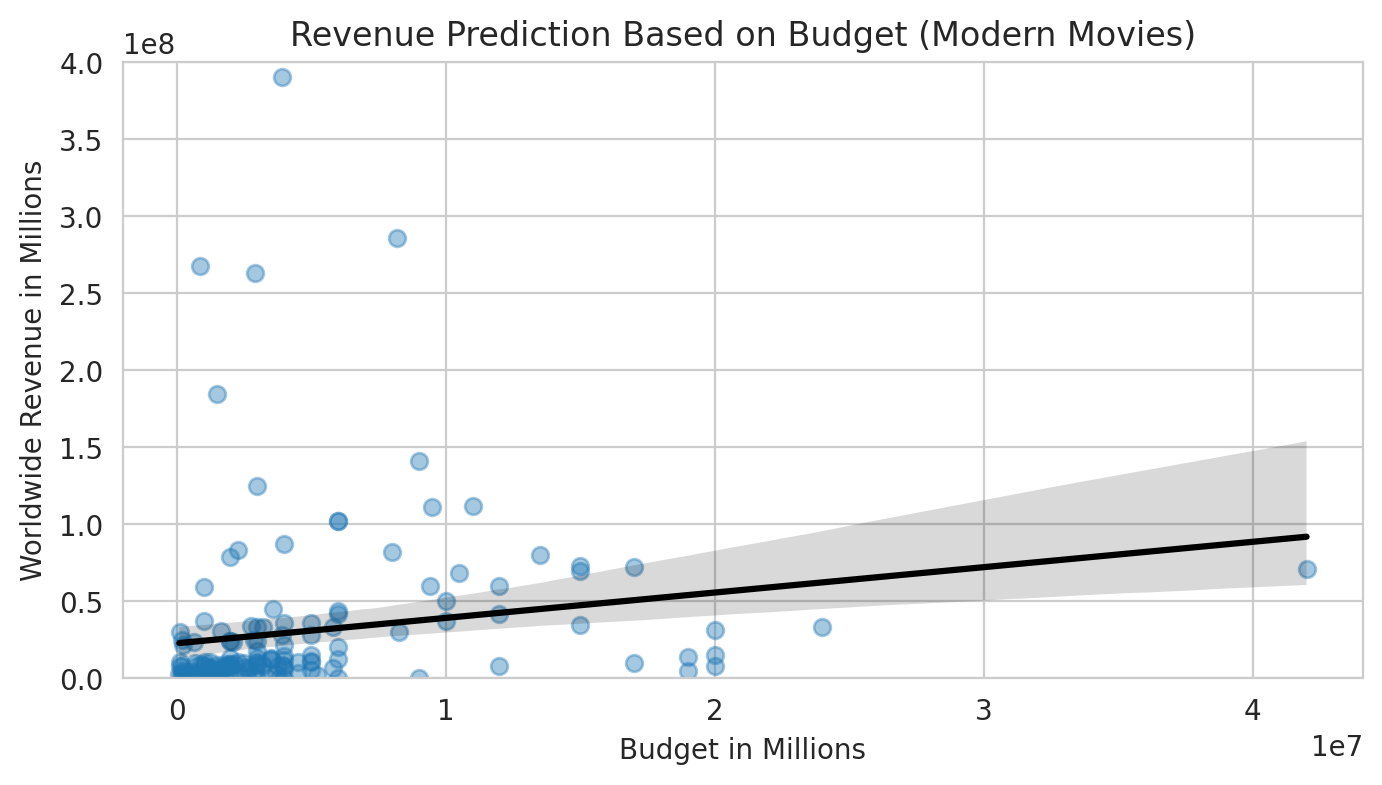

In [ ]:
plt.figure(figsize=(8,4), dpi=200)

with sns.axes_style("whitegrid"):
    ax = sns.regplot(
        old_films,
        x="USD_Production_Budget",
        y="USD_Worldwide_Gross",
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'black'}
    )

    ax.set(
        ylim=(0, 400_000_000),
        xlabel="Production budget ($)",
        ylabel="Worldwide revenue ($)",
        title="Budget vs Revenue for Films Released Before 1970"
    )

plt.tight_layout()
plt.savefig("visuals/regression_old_movies.png", dpi=300)


### Modern era regression
This regression line estimates how strongly production budget predicts worldwide gross for movies released from 1970 onward.


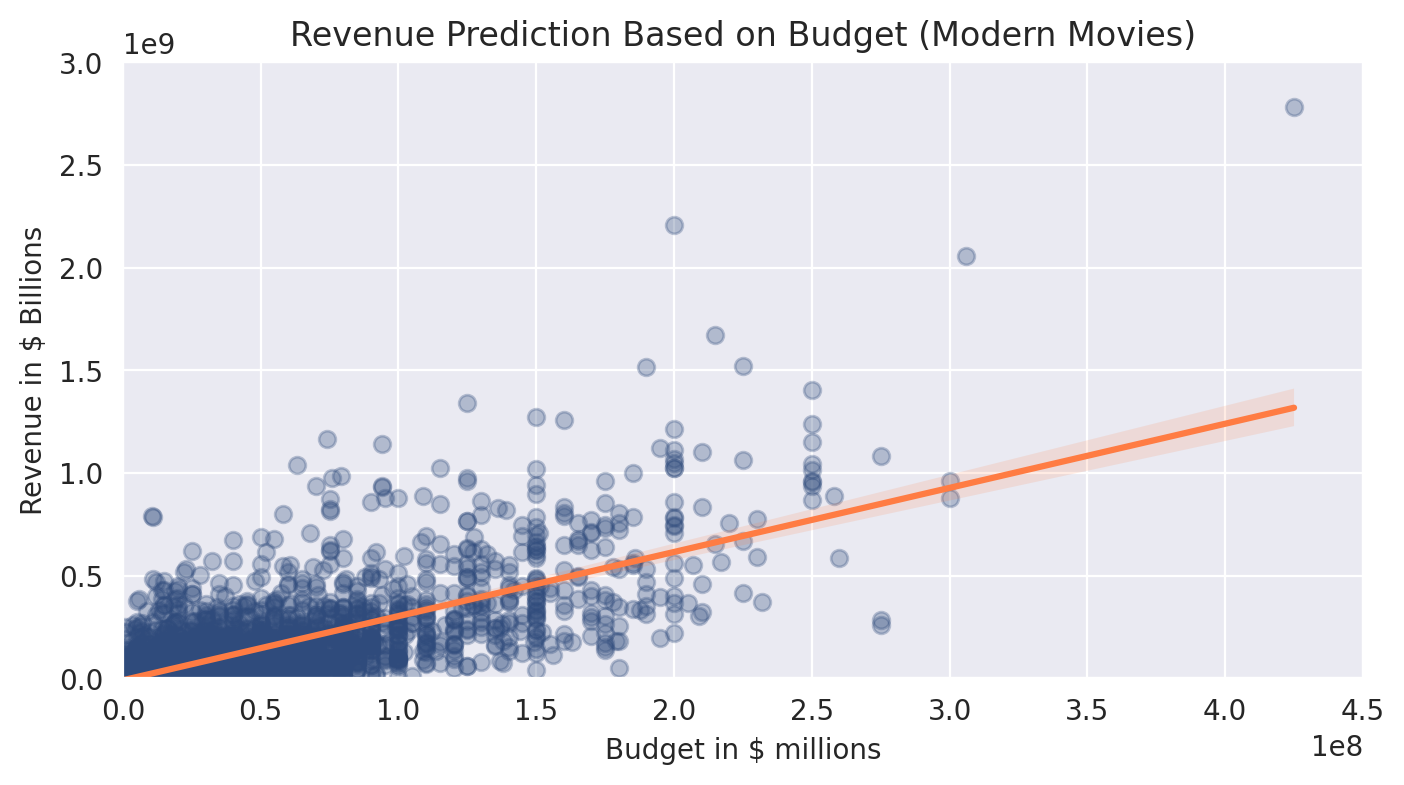

In [ ]:
plt.figure(figsize=(8,4), dpi=200)

with sns.axes_style("darkgrid"):
    ax = sns.regplot(
        new_films,
        x="USD_Production_Budget",
        y="USD_Worldwide_Gross",
        scatter_kws={
            "color": "#2f4b7c",
            "alpha": 0.3
        },
        line_kws={
            "color": "#ff7c43"
        }
    )

    ax.set(
        ylim=(0, 3000000000),
        xlim=(0, 450000000),
        ylabel="Worldwide revenue ($)",
        xlabel="Production budget ($)",
        title="Revenue Prediction Based on Budget for Modern Movies"
    )

plt.tight_layout()
plt.savefig("visuals/regression_new_movies.png", dpi=300)


### Insight
The modern-era regression is more decision-useful because it reflects a market structure closer to today's studio environment.  
A stronger fit means budget can serve as a more credible planning variable for recent films than for older titles.


## 12. Build a Simple Forecasting Model

We now fit a linear regression model to estimate expected worldwide revenue from production budget.

**Model form:**

$$
\hat{Revenue} = \theta_0 + \theta_1 \times Budget
$$


In [ ]:
from sklearn.linear_model import LinearRegression

X = new_films[["USD_Production_Budget"]]
y = new_films["USD_Worldwide_Gross"]

new_films_model = LinearRegression()
new_films_model.fit(X, y)

intercept = new_films_model.intercept_
slope = new_films_model.coef_[0]
r2 = new_films_model.score(X, y)

print(f"Intercept (θ₀): {intercept:,.2f}")
print(f"Slope (θ₁): {slope:.4f}")
print(f"R² score: {r2:.4f}")

future_budget = 350_000_000
predicted_revenue = new_films_model.predict(pd.DataFrame({'USD_Production_Budget': [future_budget]}))[0]

print(f"Estimated revenue for a budget of $350,000,000: ${predicted_revenue:,.2f}")


Intercept (θ₀): -8,650,768.01
Slope (θ₁): 3.1226
R² score: 0.5577
Estimated revenue for a budget of $350,000,000: $1,084,257,803.06


c:\proj\Seaborn+Linear+Regression\seaBenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Compare with older films
A second regression is run on films released before 1970 to test whether budget was a weaker predictor of worldwide revenue in the earlier market.


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

X = old_films[["USD_Production_Budget"]]
y = old_films["USD_Worldwide_Gross"]

model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]
r2 = model.score(X, y)

print(f"Intercept: {intercept:,.0f}")
print(f"Slope: {slope:.2f}")
print(f"R² score: {r2:.4f}")

future_budget = 350_000_000
revenue_est = model.predict(pd.DataFrame({'USD_Production_Budget': [future_budget]}))[0]
revenue_est = round(revenue_est, -6)

print(f"Estimated revenue for $350M budget: ${revenue_est:,.0f}")


Intercept: 22,821,539
Slope: 1.65
R² score: 0.0294

Estimated revenue for $350M budget: $600,000,000


c:\proj\Seaborn+Linear+Regression\seaBenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Insight
The weaker pre-1970 model reminds us that historical film markets behaved differently.  
Budget alone was a less reliable signal, so direct comparisons across eras should be made carefully.


## 13. Scenario Forecast: A \$350M Film Budget

This final section converts the regression result into a simple planning scenario:
**If a studio commits \$350 million to production, what level of worldwide revenue would the model expect?**


## 14. Business Takeaways

Based on the workflow above, the notebook supports four practical conclusions:

1. **Budget matters, but it is not a guarantee of success.**  
   Higher-budget movies tend to earn more revenue overall, but the spread in outcomes shows that execution, release quality, and audience demand still matter.

2. **Commercial risk remains meaningful.**  
   A noticeable share of released films still failed to recover production cost from worldwide gross alone.

3. **International performance can change the story.**  
   Some titles showed zero domestic revenue but still generated worldwide returns, which highlights the importance of global distribution.

4. **The budget-revenue relationship is stronger in the modern era.**  
   The regression on newer films generally provides a more useful planning signal than the same model on older films.
